📊 **Data Visualization**

In [4]:
import re
import nltk
import pandas as pd
import seaborn as sns
from wordcloud import STOPWORDS
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from nltk.probability import FreqDist
from nltk.tokenize import word_tokenize

In [5]:
df= pd.read_csv('./cyberbullying_tweets_classifiers.csv')
df = df.dropna(how='any')
df.head()

,text,type,label
0,rape realzvasiyana enema joke drunk gay lesbia...,gender,0
1,never saw celebrity say anything like obama b ...,gender,0
2,user mean gay us gendered slur make rape joke,gender,0
3,between user user user user feminacy,gender,0
4,rape rape fact read one post guy getting raped...,gender,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38918 entries, 0 to 38919
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    38918 non-null  object
 1   type    38918 non-null  object
 2   label   38918 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


Comments Distribution on Labels (balanced dataset)

In [7]:
cyberbullying_types = df['type'].unique().tolist()
print(cyberbullying_types)

['gender', 'religion', 'other_cyberbullying', 'age', 'ethnicity']


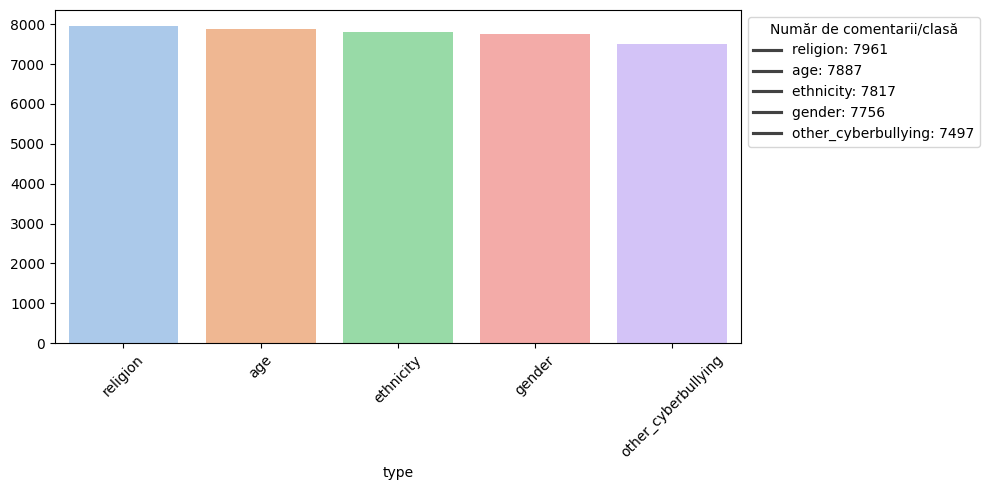

In [10]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=type_counts.index, y=type_counts.values, hue=type_counts.index, palette="pastel", legend=False)

plt.xticks(rotation=45)

legend_labels = [f"{label}: {count}" for label, count in type_counts.items()]
plt.legend(legend_labels, title="Număr de comentarii/clasă", loc="upper left", bbox_to_anchor=(1, 1))  

plt.tight_layout()

plt.show()


Word Count Ranges

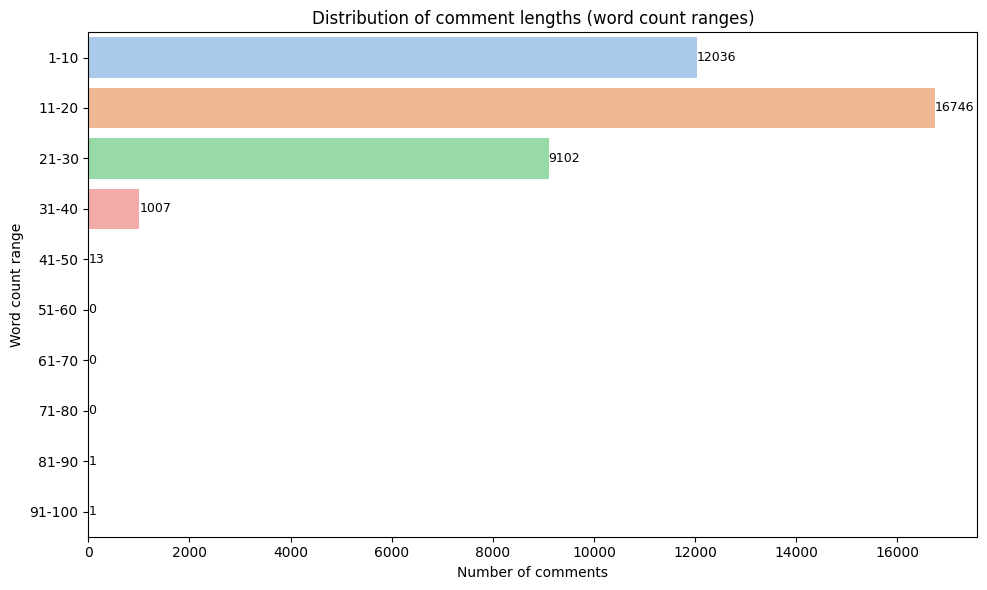

In [7]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))

bins = list(range(0, 101, 10))  # [0,10), [10,20), ..., [90,100]
labels = [f"{i+1}-{i+10}" for i in bins[:-1]]

df['word_count_group'] = pd.cut(df['word_count'], bins=bins, labels=labels, right=True, include_lowest=True)

grouped_counts = df['word_count_group'].value_counts().sort_index().reset_index()
grouped_counts.columns = ['word_count_range', 'count']

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=grouped_counts,
    x='count',
    y='word_count_range',
    hue='word_count_range',
    palette='pastel',
    legend=False
)

for i, v in enumerate(grouped_counts['count']):
    ax.text(v + 1, i, str(int(v)), color='black', va='center', fontsize=9)

plt.title("Distribution of comment lengths (word count ranges)")
plt.xlabel("Number of comments")
plt.ylabel("Word count range")
plt.tight_layout()
plt.show()

WordCloud - Visualizing the Most Common Words in Bullying Comments

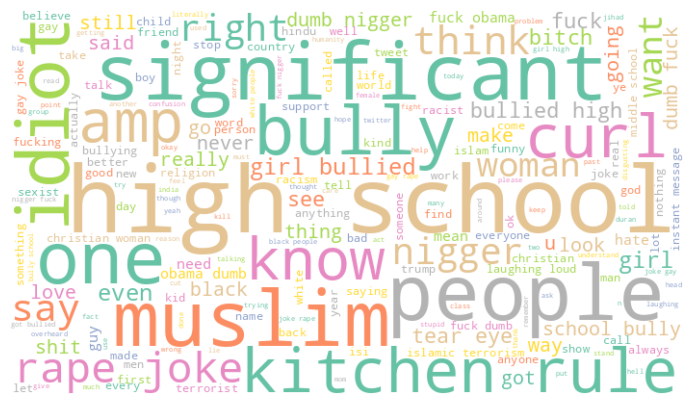

In [36]:
text = ' '.join(df['text'].astype(str).tolist())

text = ' '.join(word for word in text.split() if word.lower() != 'user')

wordcloud = WordCloud(width=700, height=400, background_color='white', colormap='Set2').generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

Word Frequency Analysis in Bullying Comments

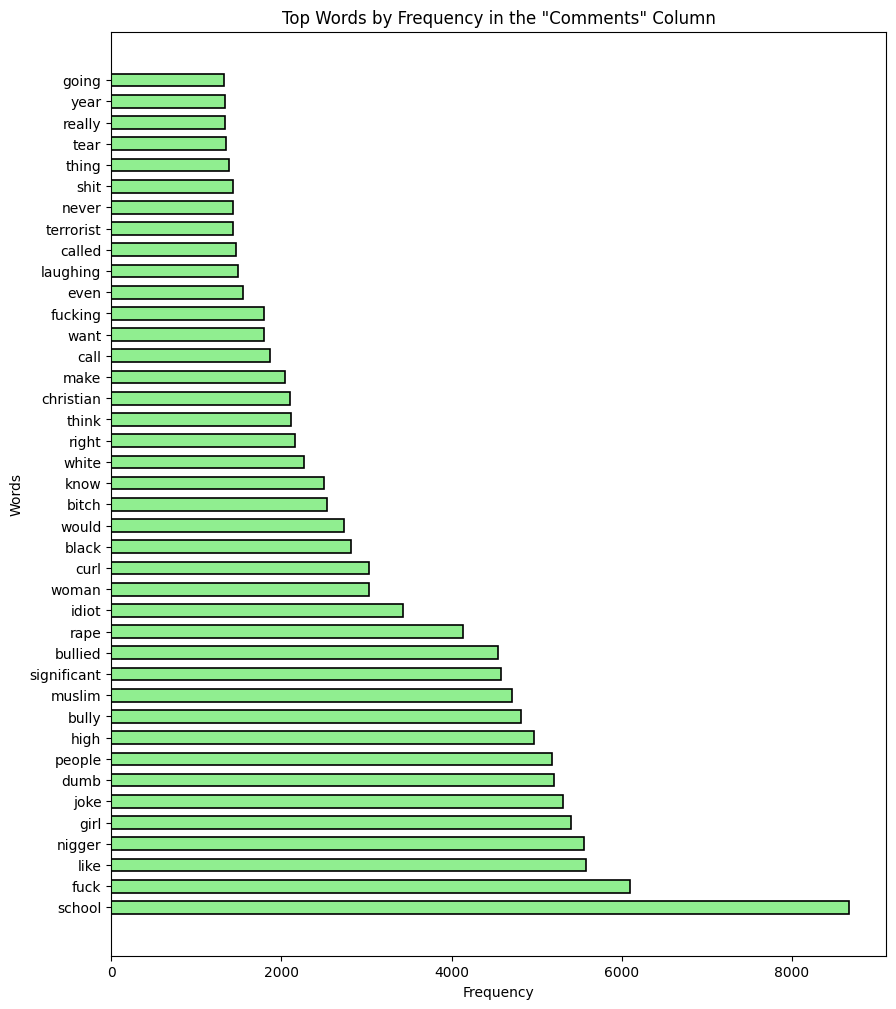

In [8]:
from nltk.corpus import stopwords as nltk_stopwords
stopwords = set(nltk_stopwords.words('english'))

data = df

all_posts = ' '.join(data['text'].values.tolist())

tokens = word_tokenize(all_posts,language='english',preserve_line=True)
filtered_tokens = [word for word in tokens if len(word) > 3 and word not in stopwords and word != 'user']
freq_dist = FreqDist(filtered_tokens)

num_top_words = 40
top_words = freq_dist.most_common(num_top_words)
top_words, frequencies = zip(*top_words)

top_words = [str(word) for word in top_words]

plt.figure(figsize=(10, 12))
bars = plt.barh(
    top_words,
    frequencies,
    color='#90ee90',
    edgecolor='black',
    linewidth=1.2,
    height=0.6
)
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.title('Top Words by Frequency in the "Comments" Column')
plt.show()

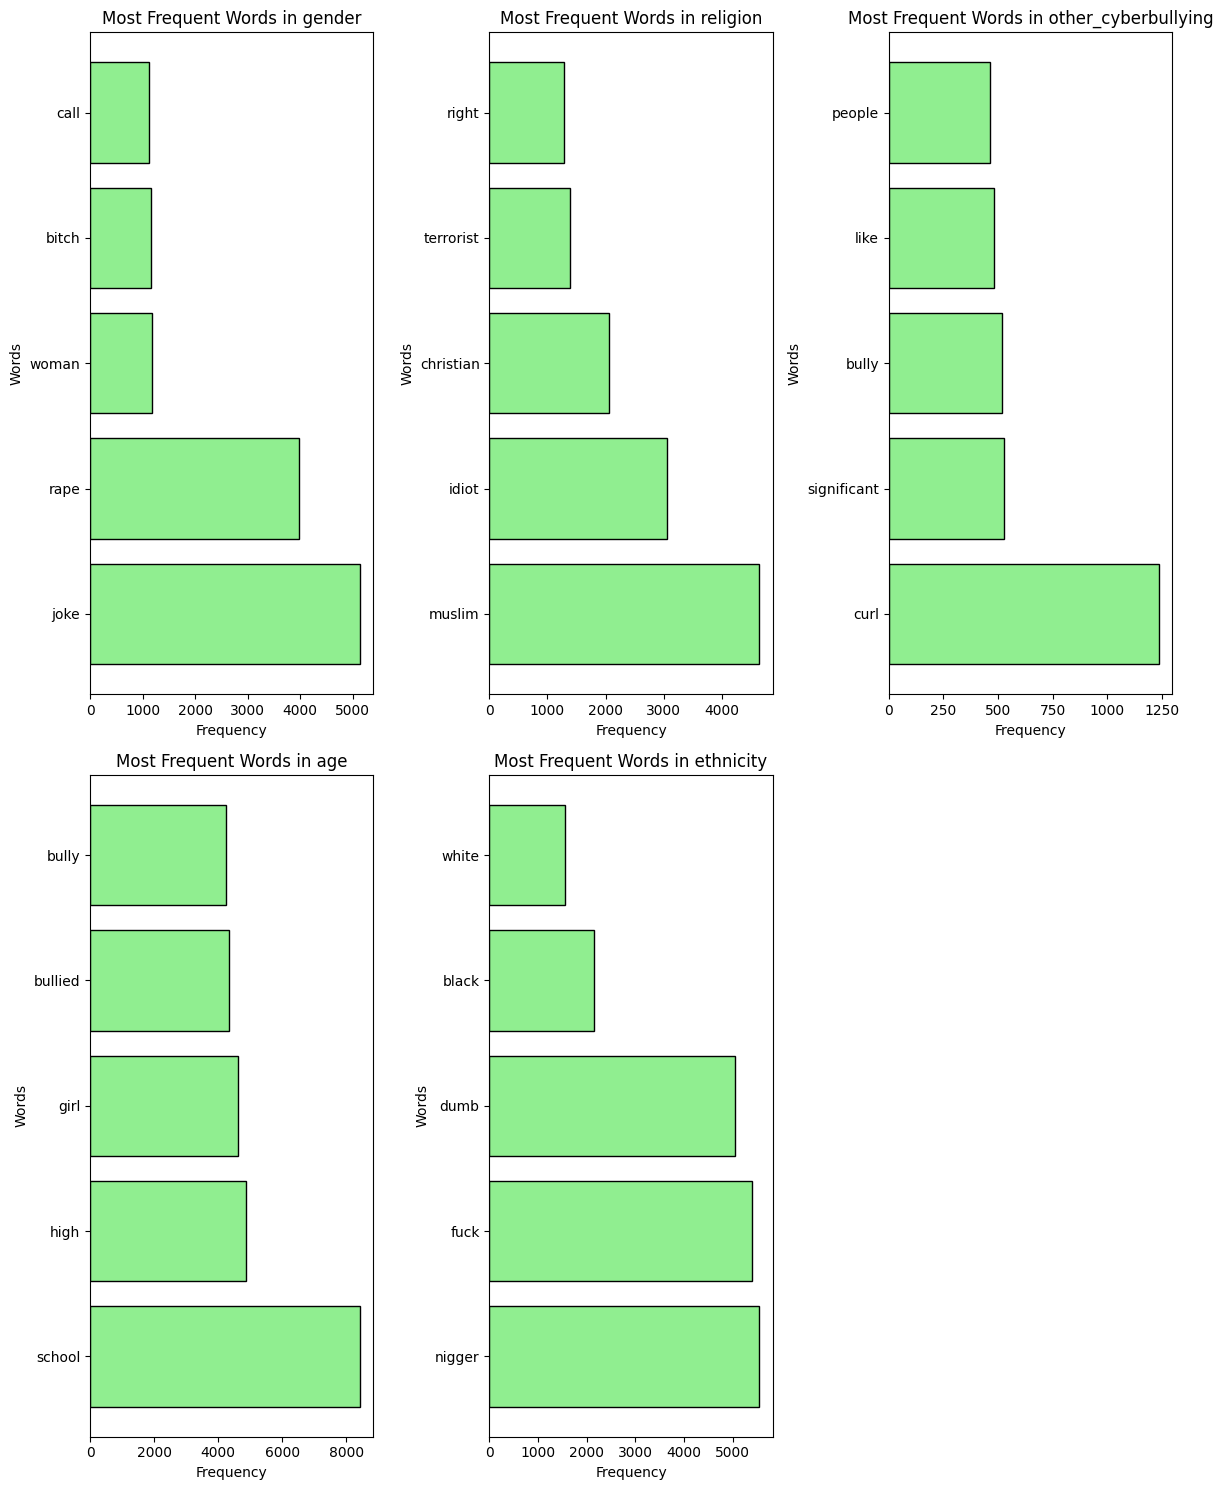

In [11]:
import matplotlib.pyplot as plt
import math

data = df
labels = data['type'].unique()

num_labels = len(labels)
num_rows = 2
num_cols = 3

fig, axes = plt.subplots(num_rows, num_cols, figsize=(12, 15))
axes = axes.flatten()

for i, label in enumerate(labels):
    filtered_data = data[data['type'] == label]
    
    all_posts = ' '.join(filtered_data['text'].values.tolist())
    all_posts = all_posts.lower()
    all_posts = re.sub(r'[^\w\s]', '', all_posts)

    tokens = word_tokenize(all_posts, language='english', preserve_line=True)
    filtered_tokens = [word for word in tokens if len(word) > 3 and word not in stopwords and word != 'user']
    
    freq_dist = FreqDist(filtered_tokens)

    num_top_words = 5
    top_words = freq_dist.most_common(num_top_words)
    top_words, frequencies = zip(*top_words)

    top_words = [str(word) for word in top_words]

    ax = axes[i]
    ax.barh(top_words, frequencies, color='#90ee90', edgecolor='black')
    ax.set_xlabel('Frequency')
    ax.set_ylabel('Words')
    ax.set_title(f'Most Frequent Words in {label}')

# dacă sunt mai puțin de 6 subploturi, ascunde subploturile goale
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()
